# Multicell wakefield under uncertainty

> Uncertainty quantification plugs into every analysis. Add a `uq_config` and the
> analysis is evaluated over a quadrature of the uncertain geometry, returning a
> distribution (mean, standard deviation) instead of a single number.

The [simplecell wakefield-UQ example](../advanced/wakefield_uq.ipynb) perturbs a cavity's
mid/end-cell parameter *groups*. Multicell UQ
(`uq_config['cell_complexity'] = 'multicell'`) goes finer: every half-cell becomes an
independent random variable, subject to the equator/iris continuity constraints — the same
parameterisation the [eigenmode multicell UQ/SA example](../eigenmode/multicell_uq_sa.ipynb)
uses, now driving the ABCI wakefield solve.

The ABCI backend needs no special handling: the deck is written from the cavity's
`profile()`, which already renders an independently-varying multicell contour, so each
perturbed variant produces a correct deck automatically.

In [1]:
import os
import tempfile
import warnings

import pandas as pd

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style

warnings.filterwarnings('ignore')
apply_style()

## 1. A two-cell cavity and its uncertainty

A two-cell TESLA-like cavity. We put a manufacturing tolerance on the equator radius
`Req`. `delta` is an additive perturbation in millimetres (not a fraction), so
`delta=[0.3]` is a realistic ±0.3 mm equator tolerance — a perturbation much smaller
than this leaves the impedance unchanged to the solver's numerical resolution.

Under `cell_complexity='multicell'` the shared entries collapse to one random variable
each — `Req` is shared by a cell's two halves, so a two-cell cavity has two
independent `Req` random variables (one per cell). UQ runs through `Study`, not a bare
`Cavity`.

In [2]:
cavs = Study(os.path.join(tempfile.mkdtemp(), 'mc_wake_uq'))
mid = [42, 42, 12, 19, 35, 57.7, 103.353]
cavs.add_cavity([EllipticalCavity(2, mid, mid, mid, beampipe='both')], ['W'])

config = {
    'MROT': 2, 'wakelength': 5, 'bunch_length': 25, 'processes': 1,
    'uq_config': {
        'variables': ['Req'],
        'delta': [0.3],                         # +/- 0.3 mm equator tolerance (additive, mm)
        'objectives': [['min', 'ZL', [0.2, 2.0, 5.0]],
                       ['min', 'ZT', [0.2, 2.0, 5.0]]],
        'method': ['Quadrature', 'Stroud3'],
        'cell_complexity': 'multicell',
        'processes': 1,
    },
}

## 2. Run it

Every quadrature node is a full ABCI wakefield solve on a perturbed multicell geometry,
so this is the slowest of the UQ examples. `MROT=2` asks for both the longitudinal
(`ZL`) and transverse (`ZT`) impedance; the objectives read the peak `|Z|` in each
frequency window (in GHz — a flat `[lo, mid, hi]` list defines the windows
`lo<f<mid` and `mid<f<hi`).

In [3]:
cavs.run_wakefield(config)
uq = cavs.uq_hom_results['W']
print('windows:', list(uq))

windows: ['ZL [max(0.2<f<2.0)]', 'ZL [max(2.0<f<5.0)]', 'ZT [max(0.2<f<2.0)]', 'ZT [max(2.0<f<5.0)]']


## 3. The impedance spread

For each window the result carries the mean (`expe`) and standard deviation
(`stdDev`) of the peak impedance across the perturbed multicell geometries — the spread
the per-cell equator tolerance induces.

In [4]:
df = pd.DataFrame({
    w: {'mean [Ohm(/m)]': v['expe'][0], 'std [Ohm(/m)]': v['stdDev'][0]}
    for w, v in uq.items()
}).T
df.round(3)

,mean [Ohm(/m)],std [Ohm(/m)]
ZL [max(0.2<f<2.0)],29.379,0.486
ZL [max(2.0<f<5.0)],16.307,1.201
ZT [max(0.2<f<2.0)],165.462,19.104
ZT [max(2.0<f<5.0)],62.129,2.932


## 4. Mean with its uncertainty band

`plot_hom_scatter(uq=True)` draws all four windows — longitudinal and transverse — each
mean as a point with its tolerance-induced ±1σ error bar.

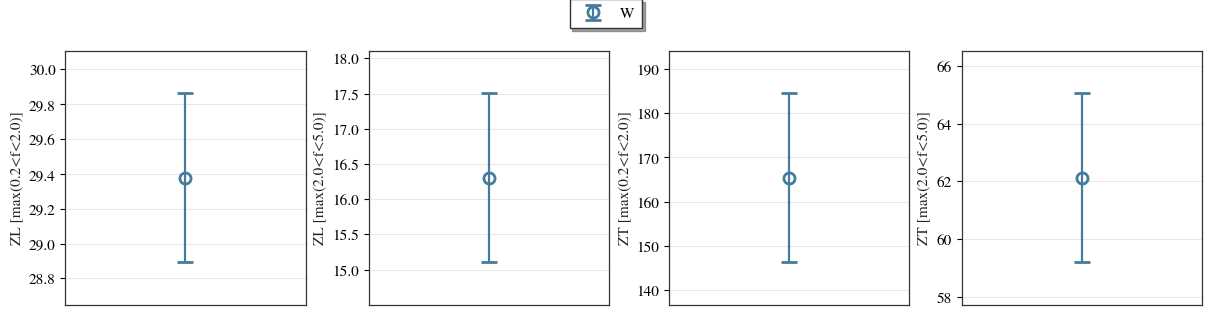

{'ZL [max(0.2<f<2.0)]': <Axes: label='ZL [max(0.2<f<2.0)]', ylabel='ZL [max(0.2<f<2.0)]'>,
 'ZL [max(2.0<f<5.0)]': <Axes: label='ZL [max(2.0<f<5.0)]', ylabel='ZL [max(2.0<f<5.0)]'>,
 'ZT [max(0.2<f<2.0)]': <Axes: label='ZT [max(0.2<f<2.0)]', ylabel='ZT [max(0.2<f<2.0)]'>,
 'ZT [max(2.0<f<5.0)]': <Axes: label='ZT [max(2.0<f<5.0)]', ylabel='ZT [max(2.0<f<5.0)]'>}

In [5]:
cavs.wakefield.plot_hom_scatter(uq=True)

The `std` columns are the headline: a per-cell equator-radius tolerance of a few tenths
of a millimetre already moves the higher-order-mode impedance by a measurable amount.

See also: the [simplecell wakefield UQ](../advanced/wakefield_uq.ipynb) (mid/end-cell
groups) and the [eigenmode multicell UQ/SA](../eigenmode/multicell_uq_sa.ipynb) (the same
independent-half-cell parameterisation, with a Sobol sensitivity analysis).